# Prior Comparison: Dirichlet vs Categorical4

This notebook compares two failure-mode parameterizations:
- **Dirichlet**: Continuous simplex prior over $(p_\text{none}, p_f, p_l)$. Mode probability $p$ also scales degradation severity, introducing $p \times \beta_f$ confounding.
- **Categorical4**: Discrete mode $z \in \{0,1,2,3\}$ (none/fouling/leak/both). Severity controlled only by $\beta_f$ and $\beta_l$, removing confounding.

We run MCMC with both priors on the same observations to demonstrate why Categorical4 was chosen for the paper.

In [1]:
import numpyro
numpyro.set_host_device_count(4)

import sys
from pathlib import Path
sys.path.insert(0, str(Path("..") / "src"))

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm
import jax
import jax.numpy as jnp
from numpyro.infer import Predictive
from numpyro import handlers

import hx_models.heat_exchanger as hx
from hx_models.inference import (
    do_inference, pack_obs, p_to_z_mode, MODE_NAMES,
    PRIOR_LOG_BETA_F_MEAN, PRIOR_LOG_BETA_F_STD,
    PRIOR_LOG_BETA_L_MEAN, PRIOR_LOG_BETA_L_STD,
    PRIOR_LOG_LAMBDA_MEAN, PRIOR_LOG_LAMBDA_STD,
)
from hx_models.plotting import (
    plot_failure_modes_ternary, plot_failure_mode_categorical4_bars,
)
from hx_models.style import (
    apply_paper_style, PARAM_LABELS, SCENARIO_COLORS, TRUE_COLOR, SBI_COLOR,
    MODE_BAR_COLORS, save_fig,
)

apply_paper_style()
np.random.seed(42)

USE_CACHED = True
results_dir = Path("../results/prior_comparison")
results_dir.mkdir(parents=True, exist_ok=True)
figures_dir = Path("../figures")
figures_dir.mkdir(parents=True, exist_ok=True)

## 1. Prior Distributions

Visualize the key prior distributions used in the model.

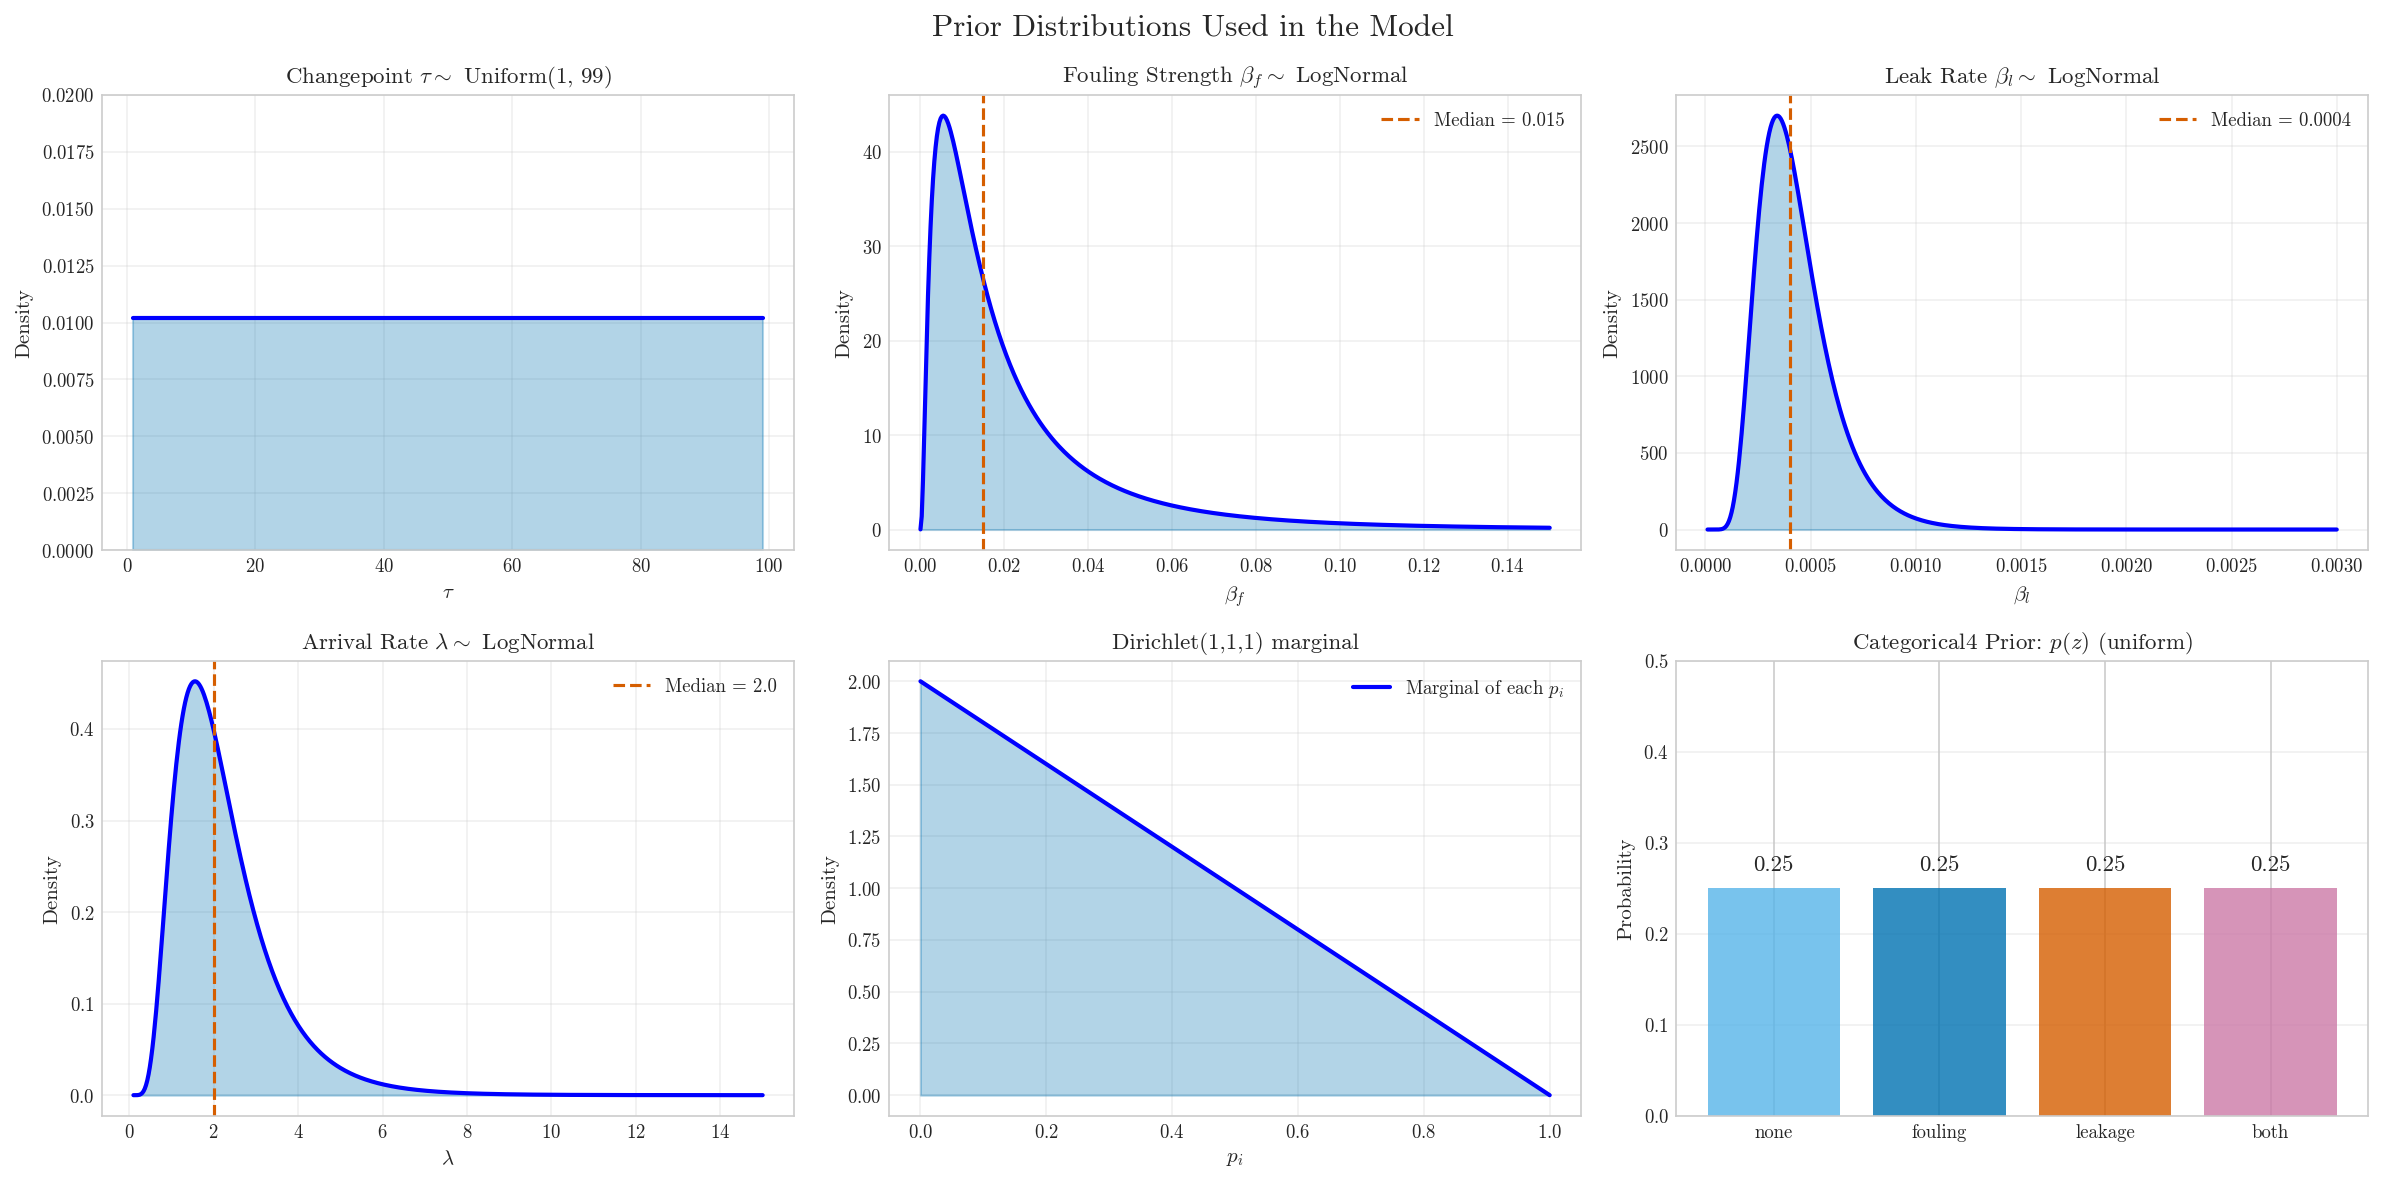

In [2]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

# tau ~ Uniform(1, 99) (from Beta(1,1) mapped)
ax = axes[0, 0]
x_tau = np.linspace(1, 99, 500)
ax.plot(x_tau, np.ones_like(x_tau) / 98.0, 'b-', lw=2)
ax.fill_between(x_tau, 0, 1/98.0, alpha=0.3, color=SBI_COLOR)
ax.set_xlabel(r'$\tau$')
ax.set_ylabel('Density')
ax.set_title(r'Changepoint $\tau \sim$ Uniform(1, 99)')
ax.set_ylim(0, 0.02)
ax.grid(True, alpha=0.3)

# beta_f ~ LogNormal
ax = axes[0, 1]
x_bf = np.linspace(0.0001, 0.15, 500)
s_bf = PRIOR_LOG_BETA_F_STD
scale_bf = np.exp(PRIOR_LOG_BETA_F_MEAN)
pdf_bf = lognorm.pdf(x_bf, s=s_bf, scale=scale_bf)
ax.plot(x_bf, pdf_bf, 'b-', lw=2)
ax.fill_between(x_bf, 0, pdf_bf, alpha=0.3, color=SBI_COLOR)
ax.axvline(scale_bf, color=TRUE_COLOR, ls='--', lw=1.5, label=f'Median = {scale_bf:.3f}')
ax.set_xlabel(r'$\beta_f$')
ax.set_ylabel('Density')
ax.set_title(r'Fouling Strength $\beta_f \sim$ LogNormal')
ax.legend()
ax.grid(True, alpha=0.3)

# beta_l ~ LogNormal
ax = axes[0, 2]
x_bl = np.linspace(0.00001, 0.003, 500)
s_bl = PRIOR_LOG_BETA_L_STD
scale_bl = np.exp(PRIOR_LOG_BETA_L_MEAN)
pdf_bl = lognorm.pdf(x_bl, s=s_bl, scale=scale_bl)
ax.plot(x_bl, pdf_bl, 'b-', lw=2)
ax.fill_between(x_bl, 0, pdf_bl, alpha=0.3, color=SBI_COLOR)
ax.axvline(scale_bl, color=TRUE_COLOR, ls='--', lw=1.5, label=f'Median = {scale_bl:.4f}')
ax.set_xlabel(r'$\beta_l$')
ax.set_ylabel('Density')
ax.set_title(r'Leak Rate $\beta_l \sim$ LogNormal')
ax.legend()
ax.grid(True, alpha=0.3)

# lambda ~ LogNormal
ax = axes[1, 0]
x_lam = np.linspace(0.1, 15, 500)
s_lam = PRIOR_LOG_LAMBDA_STD
scale_lam = np.exp(PRIOR_LOG_LAMBDA_MEAN)
pdf_lam = lognorm.pdf(x_lam, s=s_lam, scale=scale_lam)
ax.plot(x_lam, pdf_lam, 'b-', lw=2)
ax.fill_between(x_lam, 0, pdf_lam, alpha=0.3, color=SBI_COLOR)
ax.axvline(scale_lam, color=TRUE_COLOR, ls='--', lw=1.5, label=f'Median = {scale_lam:.1f}')
ax.set_xlabel(r'$\lambda$')
ax.set_ylabel('Density')
ax.set_title(r'Arrival Rate $\lambda \sim$ LogNormal')
ax.legend()
ax.grid(True, alpha=0.3)

# Dirichlet(1,1,1) - simplex visualization (triangle heatmap substitute: bar chart of marginals)
ax = axes[1, 1]
x_dir = np.linspace(0, 1, 500)
from scipy.stats import beta as beta_dist
pdf_dir = beta_dist.pdf(x_dir, 1, 2)  # Marginal of Dirichlet(1,1,1)
ax.plot(x_dir, pdf_dir, 'b-', lw=2, label='Marginal of each $p_i$')
ax.fill_between(x_dir, 0, pdf_dir, alpha=0.3, color=SBI_COLOR)
ax.set_xlabel('$p_i$')
ax.set_ylabel('Density')
ax.set_title(r'Dirichlet(1,1,1) marginal')
ax.legend()
ax.grid(True, alpha=0.3)

# Categorical4 prior (uniform for fair comparison)
ax = axes[1, 2]
cat4_probs_uniform = [0.25, 0.25, 0.25, 0.25]
bars = ax.bar([0, 1, 2, 3], cat4_probs_uniform, color=MODE_BAR_COLORS, alpha=0.8)
ax.set_xticks([0, 1, 2, 3])
ax.set_xticklabels(['none', 'fouling', 'leakage', 'both'])
ax.set_ylim(0, 0.5)
ax.set_ylabel('Probability')
ax.set_title(r'Categorical4 Prior: $p(z)$ (uniform)')
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, 0.27, '0.25', ha='center', fontsize=11)
ax.grid(True, axis='y', alpha=0.3)

fig.suptitle('Prior Distributions Used in the Model', fontsize=15, fontweight='bold')
plt.tight_layout()
save_fig(fig, figures_dir / "prior_distributions")
plt.show()

## 2. Generate Observations for Comparison

We compare the two priors across all 6 scenarios (fouling, leakage, and no-failure).

In [3]:
PRIOR_MEDIAN_BETA_F = np.exp(PRIOR_LOG_BETA_F_MEAN)
PRIOR_MEDIAN_BETA_L = np.exp(PRIOR_LOG_BETA_L_MEAN)
PRIOR_MEDIAN_LAMBDA = np.exp(PRIOR_LOG_LAMBDA_MEAN)

COMPARISON_SCENARIOS = {
    "scenario_1_normal_operation": {
        "T": 100, "tau": 18.0,
        "p": [0.0, 1.0, 0.0],
        "beta_f": 0.005, "beta_l": PRIOR_MEDIAN_BETA_L, "lambda_rate": 5.0,
    },
    "scenario_2_batch_shutdown": {
        "T": 100, "tau": 18.0,
        "p": [0.0, 1.0, 0.0],
        "beta_f": 0.03, "beta_l": PRIOR_MEDIAN_BETA_L, "lambda_rate": 0.5,
    },
    "scenario_3_boiler_feedwater": {
        "T": 100, "tau": 18.0,
        "p": [0.0, 1.0, 0.0],
        "beta_f": 0.05, "beta_l": PRIOR_MEDIAN_BETA_L, "lambda_rate": 3.0,
    },
    "scenario_4_mild_tube_leak": {
        "T": 100, "tau": 18.0,
        "p": [0.0, 0.0, 1.0],
        "beta_f": PRIOR_MEDIAN_BETA_F, "beta_l": 0.0005, "lambda_rate": PRIOR_MEDIAN_LAMBDA,
    },
    "scenario_5_severe_tube_leak": {
        "T": 100, "tau": 18.0,
        "p": [0.0, 0.0, 1.0],
        "beta_f": PRIOR_MEDIAN_BETA_F, "beta_l": 0.001, "lambda_rate": PRIOR_MEDIAN_LAMBDA,
    },
    "scenario_6_no_failure": {
        "T": 100, "tau": 18.0,
        "p": [1.0, 0.0, 0.0],
        "beta_f": PRIOR_MEDIAN_BETA_F, "beta_l": PRIOR_MEDIAN_BETA_L, "lambda_rate": PRIOR_MEDIAN_LAMBDA,
    },
}

SCENARIO_LABELS = {
    "scenario_1_normal_operation": "Normal Operation",
    "scenario_2_batch_shutdown": "Batch Shutdown",
    "scenario_3_boiler_feedwater": "Boiler Feedwater",
    "scenario_4_mild_tube_leak": "Mild Tube Leak",
    "scenario_5_severe_tube_leak": "Severe Tube Leak",
    "scenario_6_no_failure": "No Failure",
}

observations = {}
true_signals = {}

for name, cfg in COMPARISON_SCENARIOS.items():
    T_sc = cfg["T"]
    tau01 = (cfg["tau"] - 1.0) / (T_sc - 2.0)
    rng_key = jax.random.PRNGKey(abs(hash(name)) % 10000)
    
    condition_data = {
        "tau01": tau01,
        "p": jnp.array(cfg["p"]),
        "beta_f": cfg["beta_f"],
        "beta_l": cfg["beta_l"],
        "lambda_rate": cfg["lambda_rate"],
    }
    model = handlers.condition(hx.HX_with_failure_loop, data=condition_data)
    predictive = Predictive(model, num_samples=1)
    sim = predictive(rng_key, T=T_sc, hard_step=True)
    
    obs = pack_obs(sim)
    observations[name] = obs
    
    sq = lambda x: np.asarray(x).squeeze()
    true_signals[name] = {
        "tau": float(sq(sim["tau"])),
        "fouling_F": sq(sim["fouling_F_t"]),
        "leak_frac": sq(sim["leak_frac_t"]),
        "z_mode": p_to_z_mode(cfg["p"]),
    }
    print(f"Generated observation for {name}")

Generated observation for scenario_1_normal_operation
Generated observation for scenario_2_batch_shutdown
Generated observation for scenario_3_boiler_feedwater
Generated observation for scenario_4_mild_tube_leak
Generated observation for scenario_5_severe_tube_leak
Generated observation for scenario_6_no_failure


## 3. Run MCMC with Both Priors

For each scenario, we run MCMC inference with both the Dirichlet and Categorical4 prior.

In [4]:
posteriors = {}

for name, cfg in COMPARISON_SCENARIOS.items():
    T_sc = cfg["T"]
    label = SCENARIO_LABELS[name]
    
    dirichlet_path = results_dir / f"{name}_dirichlet.npy"
    categorical_path = results_dir / f"{name}_categorical4.npy"
    
    if USE_CACHED and dirichlet_path.exists() and categorical_path.exists():
        print(f"Loading cached posteriors for {label}")
        posteriors[name] = {
            "dirichlet": np.load(dirichlet_path, allow_pickle=True).item(),
            "categorical4": np.load(categorical_path, allow_pickle=True).item(),
        }
    else:
        print(f"\nRunning MCMC for {label}...")
        obs = observations[name]
        
        # Dirichlet
        print(f"  Dirichlet prior...")
        rng_key = jax.random.PRNGKey(0)
        mcmc_dir = do_inference(rng_key, obs, T=T_sc, num_warmup=2000,
                                num_samples=3000, num_chains=4,
                                failure_mode_model="dirichlet")
        post_dir = {k: np.asarray(v) for k, v in mcmc_dir.get_samples().items()}
        
        # Categorical4 (uniform prior for fair structural comparison)
        print(f"  Categorical4 prior (uniform)...")
        rng_key = jax.random.PRNGKey(1)
        mcmc_cat = do_inference(rng_key, obs, T=T_sc, num_warmup=2000,
                                num_samples=3000, num_chains=4,
                                failure_mode_model="categorical4",
                                cat4_probs=[0.25, 0.25, 0.25, 0.25])
        post_cat = {k: np.asarray(v) for k, v in mcmc_cat.get_samples().items()}
        
        posteriors[name] = {"dirichlet": post_dir, "categorical4": post_cat}
        
        np.save(dirichlet_path, post_dir)
        np.save(categorical_path, post_cat)
        print(f"  Saved to {results_dir}")

Loading cached posteriors for Normal Operation
Loading cached posteriors for Batch Shutdown
Loading cached posteriors for Boiler Feedwater
Loading cached posteriors for Mild Tube Leak
Loading cached posteriors for Severe Tube Leak
Loading cached posteriors for No Failure


## 4. Compare Posteriors

Each figure shows the Dirichlet posterior (ternary plot, left) and Categorical4 posterior (bar chart, right) for the same scenario, making the structural difference between the two parameterizations immediately visible.

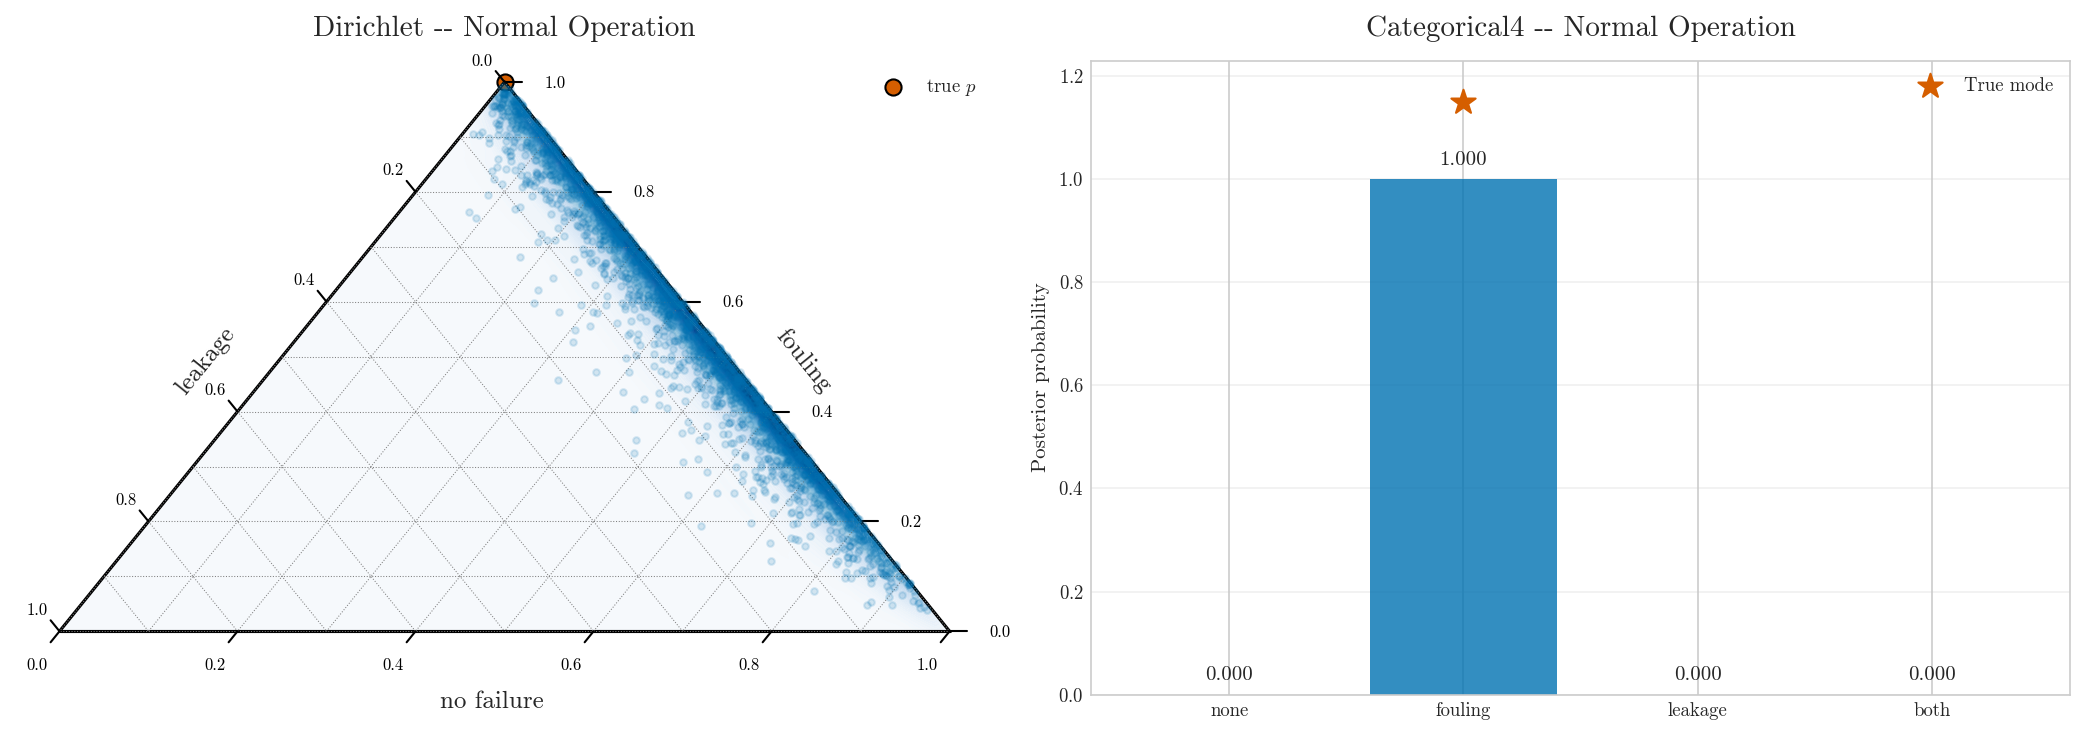

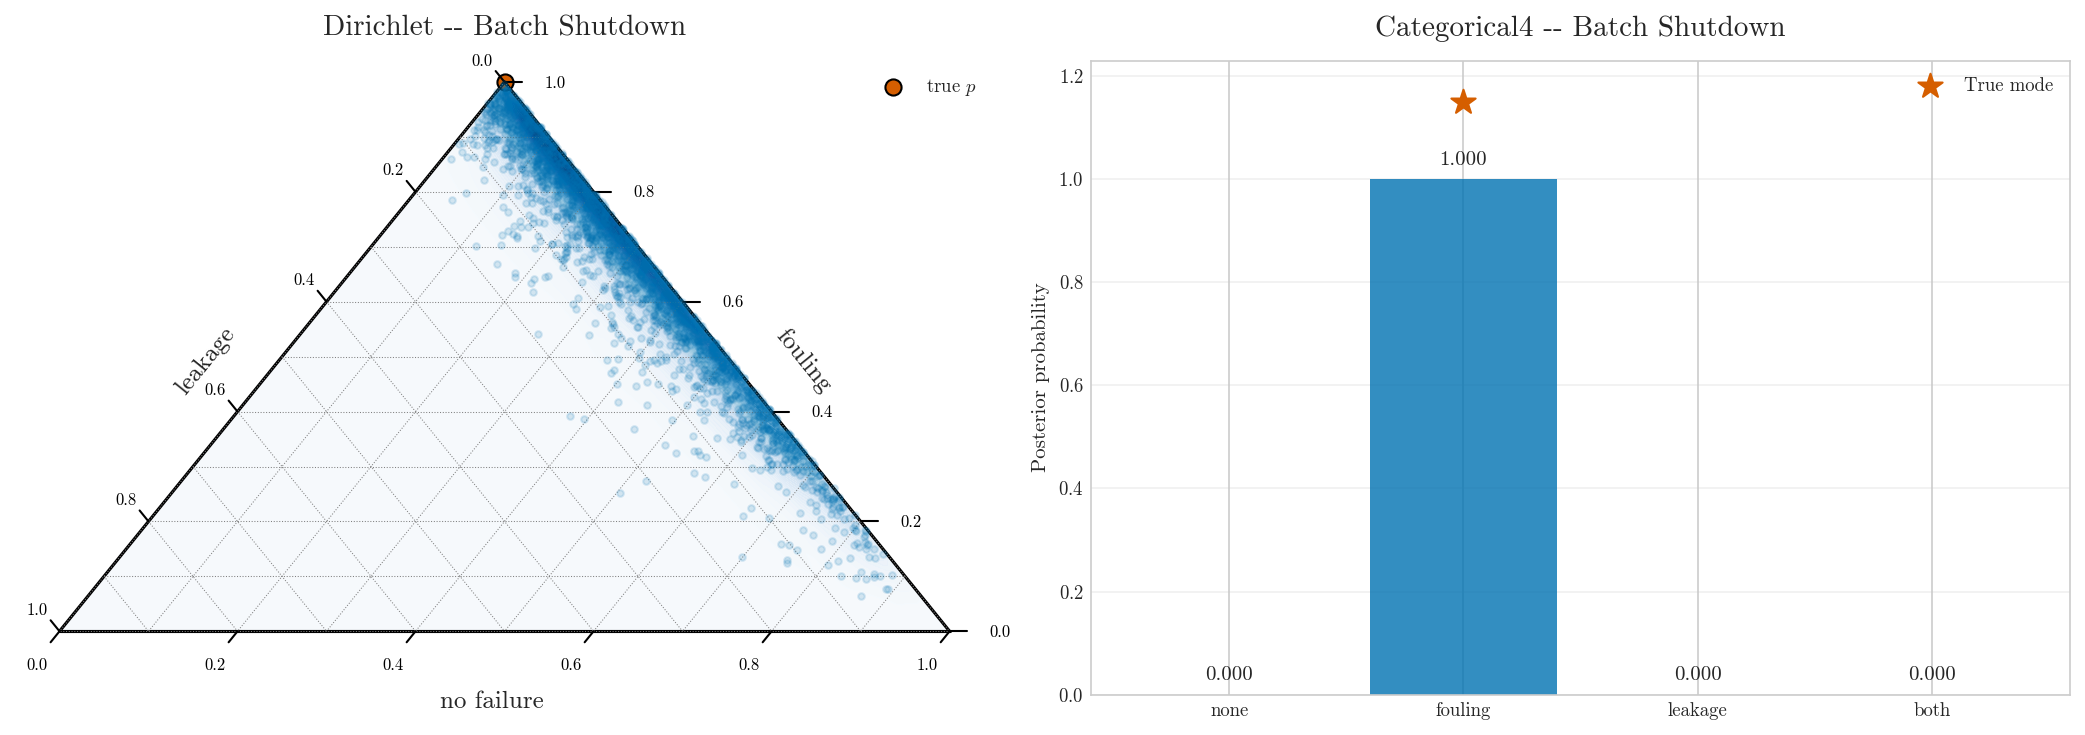

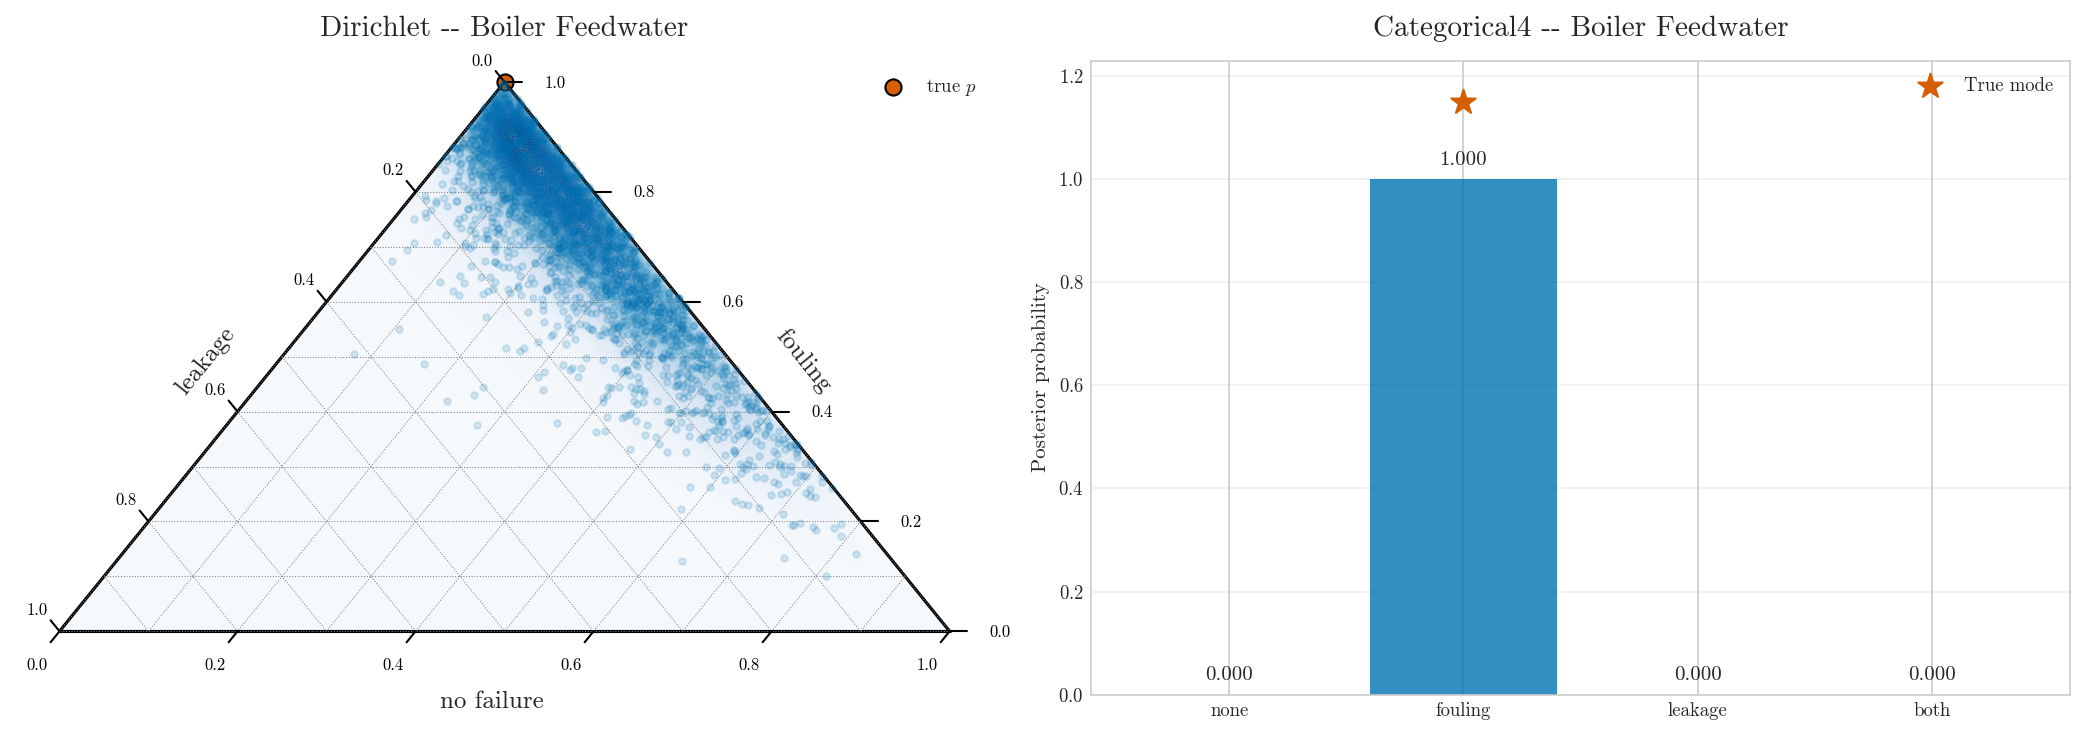

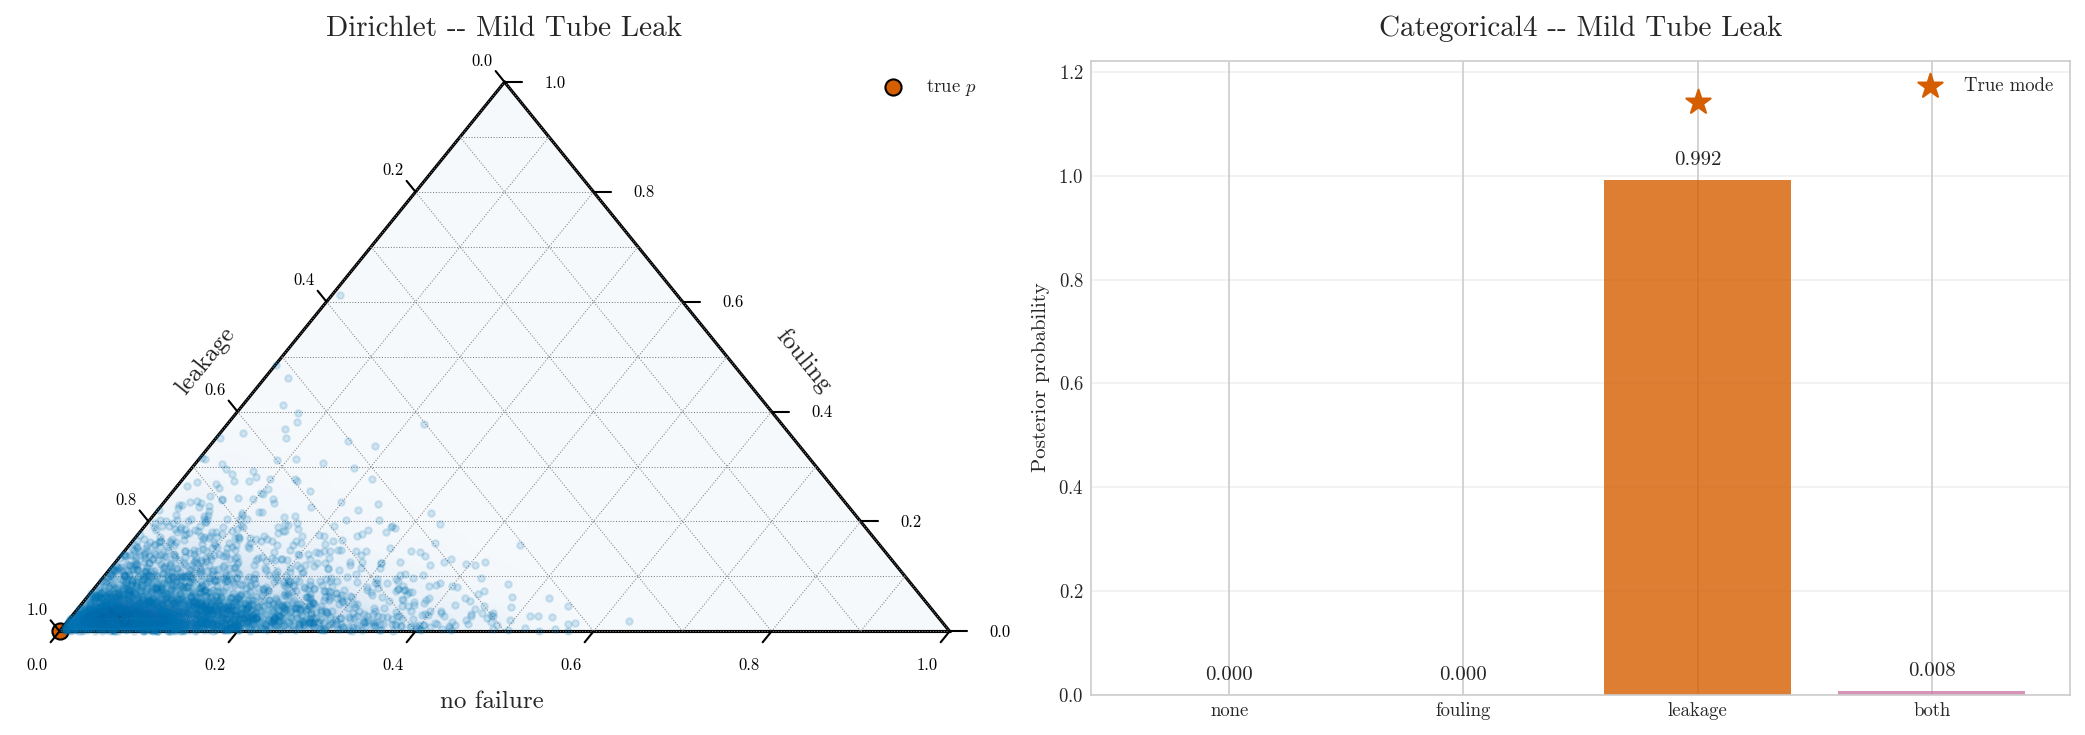

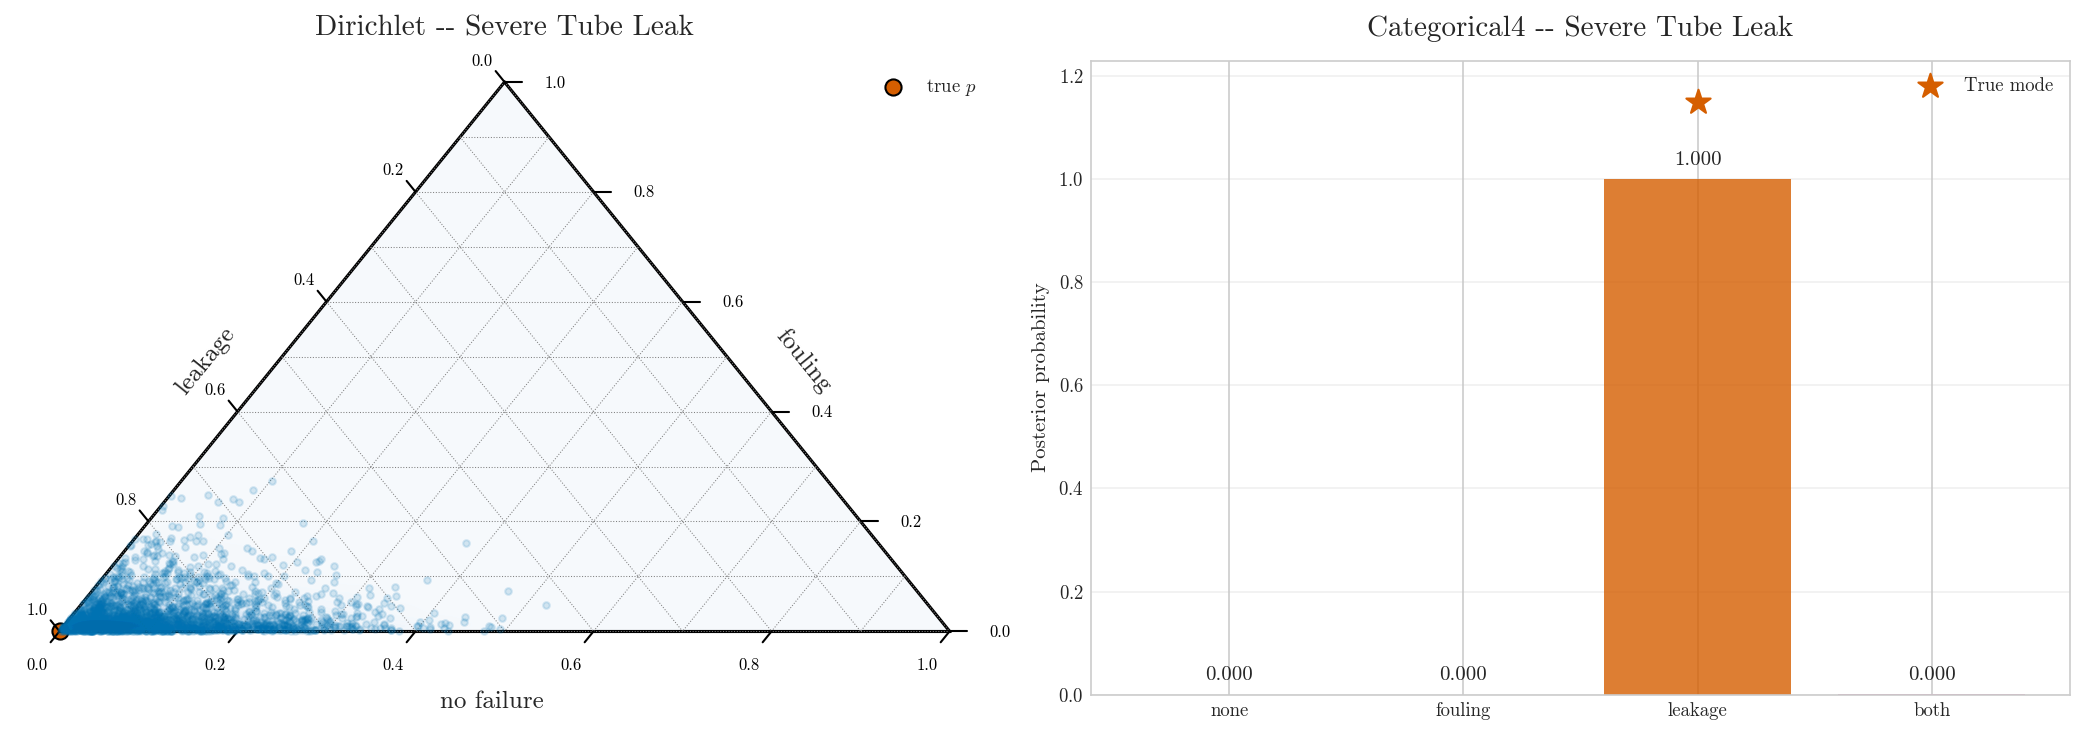

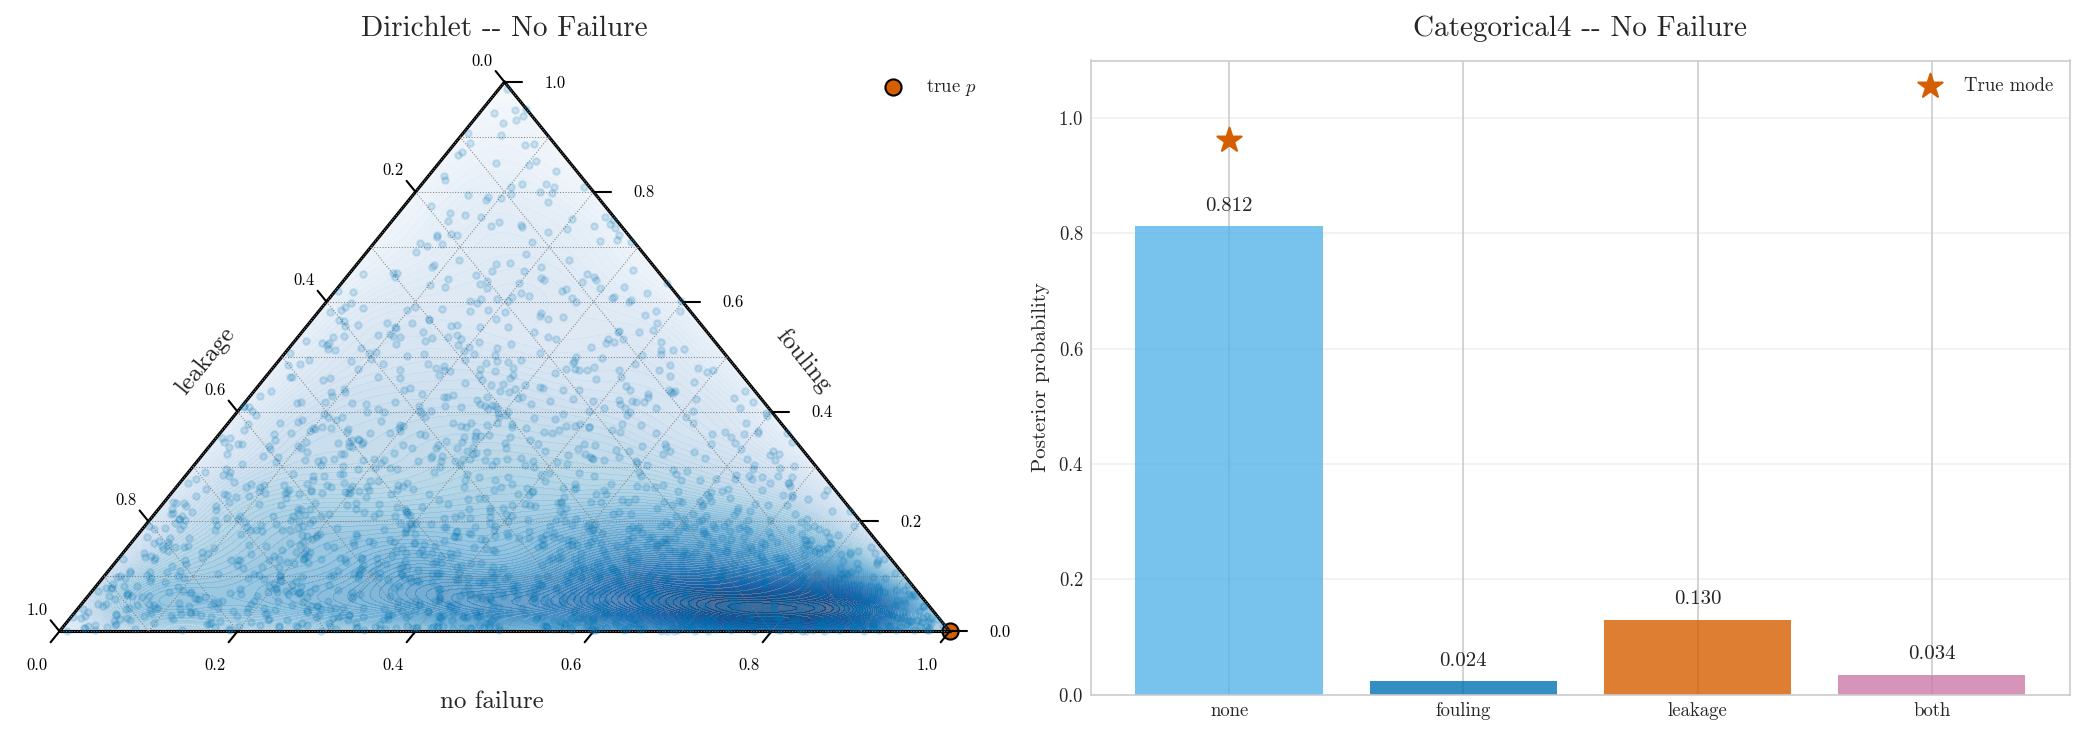

In [5]:
for name, cfg in COMPARISON_SCENARIOS.items():
    label = SCENARIO_LABELS[name]
    true = true_signals[name]
    post_dir = posteriors[name]["dirichlet"]
    post_cat = posteriors[name]["categorical4"]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5),
                             gridspec_kw={"width_ratios": [1, 1]})

    # Left: Dirichlet ternary
    p_samples = post_dir["p"]
    if p_samples.ndim == 1:
        p_samples = p_samples.reshape(-1, 3)
    plot_failure_modes_ternary(
        p_samples,
        title=f"Dirichlet -- {label}",
        true_soft_mode=cfg["p"],
        ax=axes[0],
    )

    # Right: Categorical4 bar chart
    z_samples = post_cat["z_mode"].ravel().astype(int)
    plot_failure_mode_categorical4_bars(
        z_samples,
        title=f"Categorical4 -- {label}",
        true_mode=true["z_mode"],
        ax=axes[1],
    )

    plt.tight_layout()
    save_fig(fig, figures_dir / f"{name}_prior_comparison")
    plt.show()

## 5. Summary

The comparison above uses **uniform priors** for both parameterizations — Dirichlet(1,1,1) and Categorical4 with equal weights $p(z) = 0.25$ so that any difference in posterior quality is attributable solely to the structural difference between the two formulations.

The Dirichlet parameterization spreads posterior mass across the simplex when the fouling signal is weak (e.g., Normal Operation with $\beta_f$ = 0.005), making it harder to identify the correct failure mode. The Categorical4 parameterization concentrates probability on the correct discrete mode, providing clearer diagnostic conclusions. This is because in the Dirichlet formulation, $p_f$ both selects the mode and scales the degradation severity, creating $p \times \beta_f$ confounding. The Categorical4 formulation separates mode selection from severity, allowing $\beta_f$ alone to control fouling magnitude.

### Prior tuning for the final model

Having established that Categorical4 is structurally superior, we further refine its prior for the analysis presented in the paper. In practice, heat exchangers operate normally more often than they experience failures, so we assign higher prior probability to the no-failure mode:

$$p(z) = [0.4,\; 0.2,\; 0.2,\; 0.2] \quad \text{(none, fouling, leakage, both)}$$